In [ ]:
#Calc volume of left ventricle
d0, d1, d2 = vol.meta['sampling']
dvoxel = d0 * d1 * d2
nvoxels = ndi.sum(1, labels[0], index=1)
volume = nvoxels * dvoxel
volume

## Calculate distance
A distance transformation calculates the distance from each pixel to a given point, usually the nearest background pixel. This allows you to determine which points in the object are more interior and which are closer to edges.

For this exercise, use the Euclidian distance transform on the left ventricle object in labels.

- Create a mask of left ventricle pixels (Value of 1 in labels).
- Calculate the distance to background for each pixel using ndi.distance_transform_edt(). Supply pixel dimensions to the sampling argument.
- Print out the maximum distance and its coordinates using ndi.maximum and ndi.maximum_position.
- Overlay a slice of the distance map on the original image. This has been done for you.

In [ ]:
nces
lv = np.where(labels == 1, 1, 0)
dists = ndi.distance_transform_edt(lv, sampling = vol.meta['sampling'])

# Report on distances
print('Max distance (mm):', ndi.maximum(dists))
print('Max location:', ndi.maximum_position(dists))

# Plot overlay of distances
overlay = np.where(dists[5] > 0, dists[5], np.nan) 
plt.imshow(overlay, cmap='hot')
format_and_render_plot()
Max distance (mm): 16.320510697696196
Max location: (5, 129, 137)


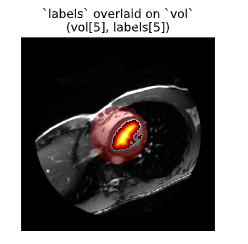

## Pinpoint center of mass
The distance transformation reveals the most embedded portions of an object. On the other hand, ndi.center_of_mass() returns the coordinates for the center of an object.

The "mass" corresponds to intensity values, with higher values pulling the center closer to it.

For this exercise, calculate the center of mass for the two labeled areas. Then, plot them on top of the image.

- Using vol and labels, calculate the center of mass for the two labeled objects. Print the coordinates.
- Use plt.scatter() to add the center of mass markers to the plot. Note that scatterplots draw from the bottom-left corner. Image columns correspond to x values and rows to y values.




In [ ]:
# Extract centers of mass for objects 1 and 2
coms = ndi.center_of_mass(vol, labels, index=[1,2])
print('Label 1 center:', coms[0])
print('Label 2 center:', coms[1])

# Add marks to plot
for c0, c1, c2  in coms:
    plt.scatter(c2, c1, s=100, marker='o')
plt.show()
Label 1 center: (4.9149927898701, 125.72786150646698, 141.42957762070142)
Label 2 center: (5.458351990999034, 121.50943176720855, 121.72954667630684)

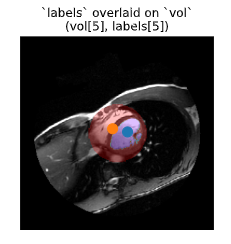